In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
two_dim = False
inputname = 'runs/10_9/H_input_2025-09-10_15-18-39.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [3]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [4]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [5]:
from concurrent.futures import ThreadPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    # usa ThreadPoolExecutor invece di ProcessPoolExecutor
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities


In [6]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

if input_plot:
    fig = plt.figure()
    if (two_dim == True):
        ax = fig.add_subplot()
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], color = 'b')
        ax.set(xlabel = 'x', ylabel = 'y', title = str(n_particles) + ' particles')
    else:
        ax = fig.add_subplot(projection='3d')
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], init_p[i][2], color = 'b', s = 1)
        ax.set(xlabel = 'x', ylabel = 'y', zlabel = 'z', title = str(n_particles) + ' particles')

    plt.show()

In [7]:
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)

Found 713 snapshots.


In [8]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 713 snapshots with 30001 particles and 3 dimensions.


### Saving CoM

In [9]:
r_CM_tot_0 = np.sum(mass[:, None] * positions[:,0,:], axis=0) / np.sum(mass)
v_CM_tot_0 = np.sum(mass[:, None] * velocities[:,0,:], axis=0) / np.sum(mass)

print("CoM position at t = 0:", r_CM_tot_0)
print("CoM velocity at t = 0:", v_CM_tot_0)

CoM position at t = 0: [ 5.38302840e-08  3.36731999e-08 -2.56113513e-09]
CoM velocity at t = 0: [ 5.89948679e-12  8.49968300e-11 -4.91554219e-12]


In [10]:
x_CM = []
y_CM = []
z_CM = []

vx_CM = []
vy_CM = []
vz_CM = []

for i in range(snap_number):
    x_CM.append(np.sum(mass * positions[:, i, 0]) /np.sum(mass))
    y_CM.append(np.sum(mass * positions[:, i, 1]) /np.sum(mass))
    z_CM.append(np.sum(mass * positions[:, i, 2]) /np.sum(mass))

    vx_CM.append(np.sum(mass * velocities[:, i, 0]) /np.sum(mass))
    vy_CM.append(np.sum(mass * velocities[:, i, 1]) /np.sum(mass))
    vz_CM.append(np.sum(mass * velocities[:, i, 2]) /np.sum(mass))

r_CM = np.array([x_CM, y_CM, z_CM])
r_CM = r_CM.transpose(1, 0)

v_CM = np.array([vx_CM, vy_CM, vz_CM])
v_CM = v_CM.transpose(1, 0)

positions_shifted  = positions  - r_CM[None, :, :]
velocities_shifted = velocities - v_CM[None, :, :]

r_CM_new = np.sum(mass[:, None, None] * positions_shifted, axis=0) / np.sum(mass)
v_CM_new = np.sum(mass[:, None, None] * velocities_shifted, axis=0) / np.sum(mass)


print("In CoM reference frame:\nCoM max position:", np.max(np.abs(r_CM_new)), "\tCoM max velocity:", np.max(np.abs(v_CM_new)))
print('BH_1 position: ', positions_shifted[0,0,:])

In CoM reference frame:
CoM max position: 4.1550921119634563e-14 	CoM max velocity: 3.083341613397704e-17
BH_1 position:  [ 4.62447545 -2.76610923 -0.47781414]


In [11]:
positions = positions_shifted
velocities = velocities_shifted

### Saving BH quantities

In [12]:
pos_BH_1 = positions[0, :, :]
vel_BH_1 = velocities[0, :, :]

### Computing radial quantities

In [13]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

In [14]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

### System mp4

### System Energy

In [15]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3][:7]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return t, E, K, U

In [16]:
time_E, E, K, U = GetEnergy(logname, n_particles)

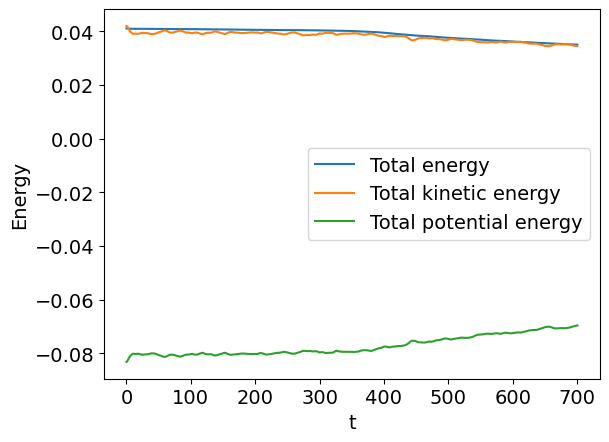

In [17]:
#plot of the energy

plt.plot(time_E, E, label="Total energy")
plt.plot(time_E, K, label="Total kinetic energy")
plt.plot(time_E, U, label="Total potential energy")
plt.xlabel("t", fontsize = 14)
plt.ylabel("Energy", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

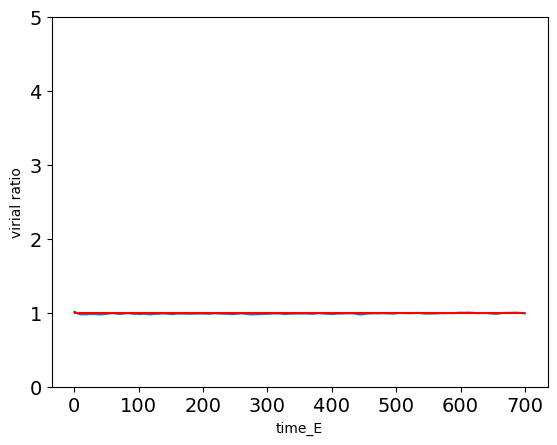

In [18]:
virial_ratio = []
for t in range(len(time_E)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

plt.plot(time_E, virial_ratio)
plt.hlines(1.0, 0, max(time_E), color = 'r')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('time_E')
plt.ylabel('virial ratio')
plt.ylim(0, 5)
plt.show()

In [19]:
print(2 * K[0] / np.abs(U[0]))

1.0114251352976547


### Lagrangian radii

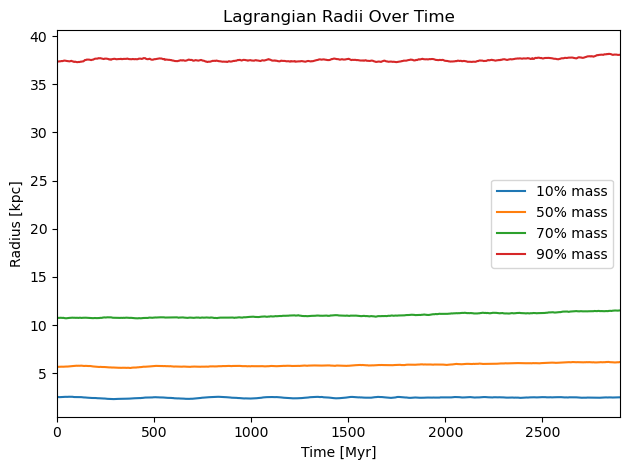

In [20]:
#compute Lagrangian radii enclosing specified mass fractions
def lagrangian_radii(pos, mass_fractions=[0.1, 0.5, 0.7, 0.9]):
    r = np.linalg.norm(pos, axis=1)  #radial distances
    r_sorted = np.sort(r)
    idxs = (np.array(mass_fractions) * len(r)).astype(int)  #indices for percentiles
    return r_sorted[idxs]

#lagrangian Radii over time
r_lag_all = []
for snap in range(snap_number):
    pos_snap = positions[:, snap, :]
    r_lag = lagrangian_radii(pos_snap)
    r_lag_all.append(r_lag)

r_lag_all = np.array(r_lag_all)

plt.figure()
for i, frac in enumerate([10, 50, 70, 90]):
    plt.plot(time*4.714829951118732, r_lag_all[:, i], label=f"{frac}% mass")

plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")
plt.title("Lagrangian Radii Over Time")
plt.xlim(0, 2900)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
#conversioni
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732  
#softening usato nel treecode
soft_pair = 0.06 # kpc

### 2D orbit

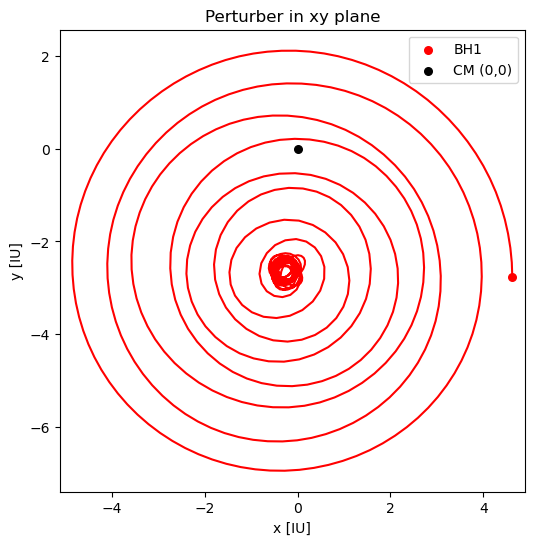

M_1 =  0.01


In [22]:
#coordinate dei due BH
x1, y1 = pos_BH_1[:, 0], pos_BH_1[:, 1]

plt.figure(figsize=(6,6))

#BH1 
plt.plot(x1, y1, color="red")
plt.scatter([x1[0]], [y1[0]], color="red", s=30, marker="o", label="BH1")
plt.scatter([x1[-1]], [y1[-1]], color="red", s=30, marker="x")

plt.plot(r_CM_new[:,0], r_CM_new[:,1], 'k--', lw=1) 
plt.scatter([0], [0], c='black', marker='o', s=30, label="CM (0,0)")

plt.xlabel("x [IU]")
plt.ylabel("y [IU]")
plt.title("Perturber in xy plane")
plt.legend()
plt.axis("equal")
plt.show()

print('M_1 = ', mass[0])

### BH radius

In [23]:
time_Myr = time * MYR_PER_IU

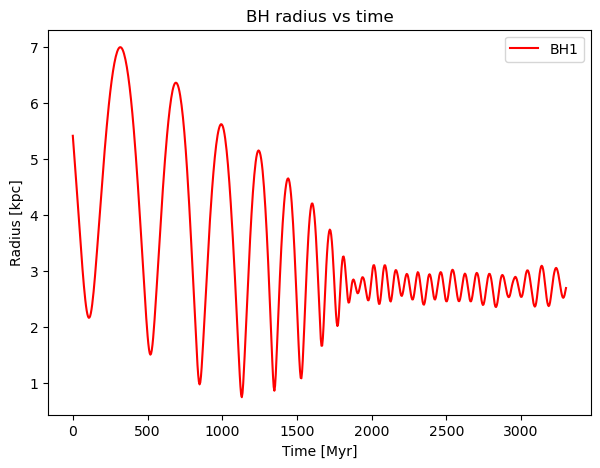

In [24]:
plt.figure(figsize=(7,5))
plt.plot(time_Myr, radius[0], label="BH1", color='red')
plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")  # 1 IU = 1 kpc
plt.title("BH radius vs time")
plt.legend()
plt.show()

### Angular momentum

In [45]:
r_rel_1 = pos_BH_1 - r_CM
v_rel_1 = vel_BH_1 - v_CM

L_BH = mass[0] * np.cross(r_rel_1, v_rel_1)
L_BH= np.sqrt(L_BH[:, 0]**2 + L_BH[:, 1]**2 + L_BH[:, 2]**2) #modulo rispetto al centro di massa

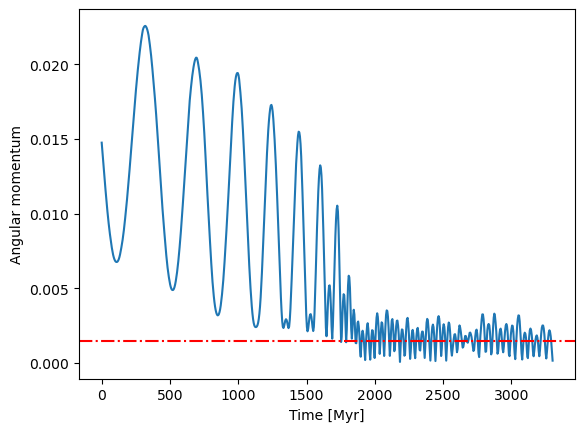

In [50]:
plt.plot(time_Myr, L_BH)
plt.axhline(L_BH_rel_1[0] / 10, c = 'r', linestyle = '-.')
plt.xlabel("Time [Myr]")
#plt.xlim([1500, 2000])
plt.ylabel("Angular momentum")
plt.show()

In [49]:
np.mean(L_BH[500:])

np.float64(0.0016602878776216798)

### Escaped particles

In [30]:
M_H = 1.0
a = 2.0
r_escape = r_lag_all[0, -1]

def v_escape (radius):
    return np.sqrt(2*M_H / (radius + a))

n_escape = 0.0
mask_escape = []

for i in tqdm(range(1, n_particles)):
    for j in range(snap_number):
        if radius[i, j] > r_escape and radial_v[i, j] >= v_escape(r_escape):
            #print('particle number ', i, f'escaped at time {time[j]:.2f}')
            mask_escape.append(i)
            n_escape += 1
            break

print('tot # of escaped particles = ', n_escape, ', corresponding to ', n_escape/n_particles, ' of the system.')

100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [00:03<00:00, 8427.71it/s]

tot # of escaped particles =  67.0 , corresponding to  0.0022332588913702876  of the system.


Perfetto — ho preparato uno script completo che implementa **più criteri pratici** per stabilire *quando dichiarare finita la dynamical friction* a partire dalla serie temporale del momento angolare nel frame CM.

Di seguito spiego le idee, poi trovi il riassunto delle regole implementate e infine come usarlo subito sui tuoi dati.

# Idee/filosofia

Non esiste un'unica definizione "corretta": la scelta dipende dallo scopo fisico. Le tre famiglie più usate sono:

1. **Soglia relativa** — L scende sotto una frazione $f$ di $L_0$ (es. 10%, 5%). semplice e interpretabile.
2. **Floor del rumore** — L scende al livello del rumore della misura (o sotto un multiplo del MAD). utile quando la serie è rumorosa.
3. **Tempo caratteristico troppo grande** — l’istante in cui $t_{\rm df}(t)=|L/(dL/dt)|$ diventa molto più grande della durata della simulazione o di un tempo di riferimento (p.e. $>5\times T_{\rm sim}$ o $>10\times$ età dell’universo se i tempi sono in Gyr): significa che la perdita di L è ormai trascurabile.
4. **Derivata trascurabile per più passi** — $|dL/dt|$ sotto una soglia (basata sul rumore) per N passi consecutivi: indica arresto stabile della perdita di momento angolare.
5. **Criterio combinato** — OR/AND sensato delle precedenti (es. dichiari "finita" se almeno una condizione robusta è soddisfatta).

# Cosa ho implementato (nel codice)

Lo script che ho eseguito calcola:

* smoothing (Savitzky–Golay) e derivata stabile dL/dt;
* stima robusta del rumore (MAD -> sigma) e noise\_floor;
* $t_{\rm df}(t)=|L|/|dL/dt|$;
* prime occorrenze temporali per ciascuna condizione:

  * `fraction_of_initial` (default: 5–10% a scelta);
  * `noise_floor` (default: k\_noise=3);
  * `tdf_long` (default: factor=5 × durata simulazione);
  * `small_derivative` (default: N consecutive steps, thresh = k × sigma\_resid);
  * `combined_default` = OR dei precedenti (primo istante in cui una di quelle condizioni è vera).
* è prodotto un plot riassuntivo e un dizionario con tempi/indici e diagnostica.

Ho eseguito una demo su dati sintetici e salvato il plot in `/mnt/data/df_finished_demo.png`.

# Raccomandazioni pratiche (valori tipici)

* `fraction`: 0.1 → 0.05 (10% o 5%) sono scelte comuni.
* `k_noise`: 2–4; usare 3 è una scelta robusta.
* `tdf_factor`: 3–10; scegliere più grande se vuoi davvero "inesistenza pratica" di DF.
* `consec_steps`: metti almeno 5–10 se il passo temporale è piccolo rispetto all’evoluzione.

# Come usarlo subito sui tuoi dati

1. Sostituisci `t` e `L_obs` nel codice con i tuoi array (o carica un CSV/npz).
2. Regola `fraction`, `k_noise`, `tdf_factor`, `consec_steps` in base al tuo rumore e alla risoluzione temporale.
3. Il codice ti restituisce un dizionario `results` con i tempi/indici corrispondenti e `diagnostics` con L smoothed, dLdt e t\_inst.

Se vuoi, subito posso:

* eseguire lo script sui tuoi dati (carica un piccolo file CSV/NPZ con colonne `time` e `L` o con le componenti di L e prendo |L| io),
* oppure modificare il criterio combinato (es. richiedere che siano soddisfatte almeno 2 dei 3 criteri prima di dichiarare "finita"),
* oppure restituire una funzione pronta da integrare nel tuo pipeline C/Python.

Dimmi pure quale preferisci — se vuoi che lavori sui tuoi dati carica il file (CSV/npz); altrimenti posso mostrarti direttamente qui la funzione da copiare nel tuo codice.
